## 1. Introduction to Machine Learning

### 1.1 Setting Up Your Environment
We need: NumPy, Pandas, Matplotlib, Scikit-Learn.

In [1]:
# Check versions
import sys
import sklearn
import numpy as np
import matplotlib
print("Python:", sys.version)
print("Scikit-learn:", sklearn.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Scikit-learn: 1.6.1


##2. Perceptron: Implementation from Scratch
Here we build our own Perceptron class to see the "guts" of the algorithm.

### 2.1 Perceptron Class

In [10]:
class Perceptron:
    ''' Perceptrone implementation

    Parameters
    ---
    eta: float, learning rate (between 0 and 1)
    n_iter: int, passes over the training set
    random_state: int, for representation

    Atributes
    ---
    weights_: weights of model after training, 1-d array
    b_: scalar, bias
    errors_: list, number misclassifications per epoch
    '''
    def __init__(self, eta=0.01, n_iter=50, random_state=42):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        ''' Training process

        Parameters
        ---
        X: array [n_samples, n_features]
        y: array [n_samples, 1], values must be -1 or 1
        '''
        rgen = np.random.RandomState(seed=self.random_state)
        self.weights_ = rgen.normal(loc=0, scale=0.1, size=X.shape[1])
        self.b_ = np.array([1.])
        self.errors_ = []
        for epoch_i in range(self.n_iter):
            errors = 0
            for sample, target in zip(X, y):
                update = self.eta * (target - self.predict(sample))
                self.weights_ += update * sample
                self.b_ += update
                errors += int(update != 0)
            if errors == 0:
                return self
            self.errors_.append(errors)
        return self

    def z_calculate(self, X):
        '''Calculate z value'''
        return np.dot(self.weights_, X) + self.b_

    def predict(self, X):
        '''Calculate prediction'''
        return np.where(self.z_calculate(X) >= 0, 1, -1)

### 2.2 Training on Real Data: Iris Dataset
Let's load the famous Fisher's Iris dataset.

In [5]:
import pandas as pd

df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data', header=None)
print(df.sample(5))

       0    1    2    3                4
18   5.7  3.8  1.7  0.3      Iris-setosa
105  7.6  3.0  6.6  2.1   Iris-virginica
9    4.9  3.1  1.5  0.1      Iris-setosa
67   5.8  2.7  4.1  1.0  Iris-versicolor
124  6.7  3.3  5.7  2.1   Iris-virginica


We'll select two classes (Setosa and Versicolor) and two features (sepal length and width) for easy visualization.

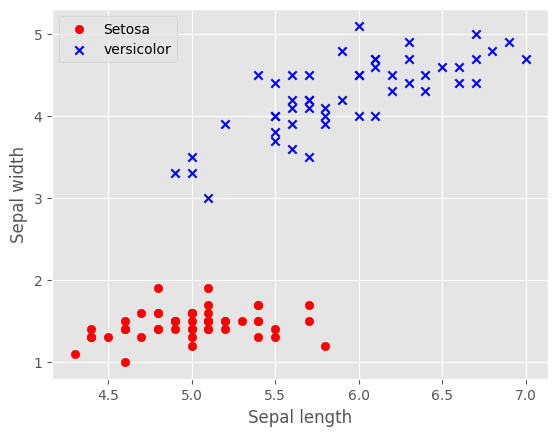

In [8]:
y = df.iloc[:100, 4].values
y = np.where(y == 'Iris-setosa', -1, 1) #convert in binary format
X = df.iloc[:100, [0, 2]].values

import matplotlib.pyplot as plt
plt.style.use('ggplot')
plt.scatter(X[:50, 0], X[:50, 1], color='red', label='Setosa', marker='o')
plt.scatter(X[50:100, 0], X[50:100, 1], color='blue', marker='x', label='versicolor')
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.legend(loc='upper left')
plt.show()

##2.3 Training and Visualizing Errors

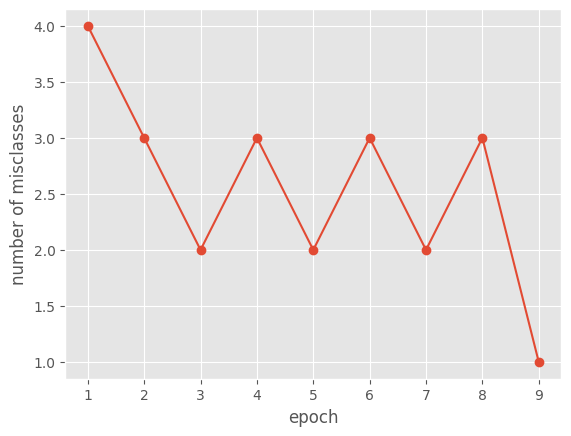

In [12]:
import warnings
warnings.filterwarnings('ignore')

ppn = Perceptron()
ppn.fit(X, y)
plt.plot(range(1, len(ppn.errors_)+1), ppn.errors_, marker='o')
plt.xlabel('epoch')
plt.ylabel('number of misclasses')
plt.show()

## 2.4 Adaline: Training via Gradient Descent
Now we implement Adaline. Key difference: we compute error using the continuous loss function.

## 2.5 The Critical Importance of Feature Scaling
Let's see how the learning rate
η affects Adaline's convergence without scaling.

In [31]:
class AdalineGD:
    '''Adaline gradient decsent classifer'''

    def __init__(self, eta=0.01, n_iter=50, random_state=42):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.weights_ = rgen.normal(loc=0, scale=00.1, size = X.shape[1])
        self.b_ = np.float32(0.)
        self.losses_ = []
        for i in range(self.n_iter):
            z = self.net_input(X)
            errors = y - z
            self.weights_ += self.eta * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * errors.mean()
            loss = (errors**2).mean()
            self.losses_.append(loss)
        return self

    def net_input(self, X):
        return np.dot(X, self.weights_) + self.b_

    def predict(self, X):
        return np.where(self.net_input(X) >= 0, 1, -1)

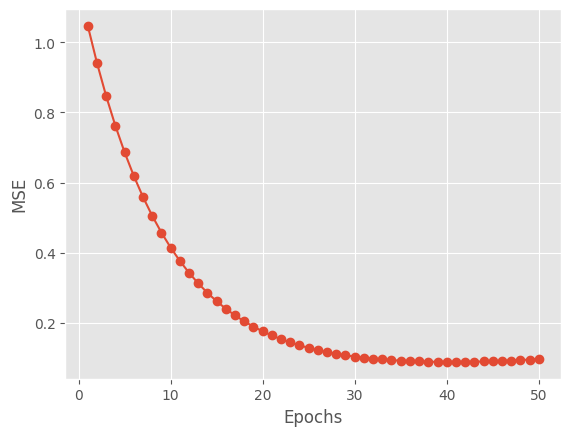

In [36]:
ada = AdalineGD(eta=0.05)
ada.fit(X, y)

plt.plot(range(1, len(ada.losses_) + 1), ada.losses_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.show()
# You'll see the loss does NOT decrease! That's the "valley" problem.
# Maybe not, if we are lucky

**Solution**: Standardization (Z-score normalization).

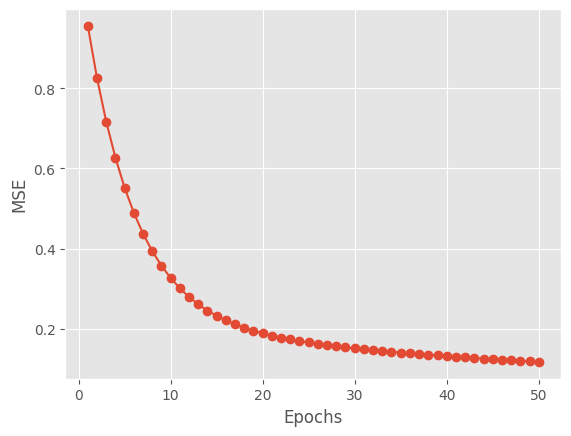

In [37]:
X_std = np.copy(X)
X_std[:, 0] = (X[:, 0] - X[:, 0].mean()) / X[:, 0].std()
X_std[:, 1] = (X[:, 1] - X[:, 1].mean()) / X[:, 1].std()

ada = AdalineGD(eta=0.05)
ada.fit(X_std, y)

# Now the loss decreases smoothly!
plt.plot(range(1, len(ada.losses_) + 1), ada.losses_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.show()

Compare our custom Adaline with sklearn.linear_model.SGDClassifier using loss 'squared_error'. Verify they give identical results.

In [38]:
from sklearn.linear_model import SGDClassifier
sgd = SGDClassifier(loss='squared_error', max_iter=50, random_state=1,
                    learning_rate='constant', eta0=0.01)
sgd.fit(X_std, y)
print(f"Sklearn accuracy: {sgd.score(X_std, y)}")

Sklearn accuracy: 1.0
